# **MÓDULO 20 - Projeto de Credit Score - Naive Bayes**


No módulo 17 vocês realizaram a primeira etapa do projeto de crédito de vocês.
Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste.
Nessa aula aplicaremos o algoritmo de naive bayes a base de vocês afim de tentarmos trazer previsões do score de crédito.

**IMPORTANTE:** Não se esqueçam de ao enviar o código de vocês para os tutores, enviarem as bases, pois como cada um de vocês realizou as alterações de tratamento indidualmente o tutor precisa ter acesso aos seus dados individuais.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score

Durante a aula nossa variável a ser prevista (churn) continha apenas 2 categorias, a base de vocês contém mais. O Naive Bayes pode ser aplicado para problemas de classificação com múltiplas classes da mesma forma que para problemas de classificação binária. O Naive Bayes é um algoritmo de classificação probabilístico que calcula a probabilidade de uma amostra pertencer a cada classe e seleciona a classe com a maior probabilidade como a previsão final.
Em resumo, o Naive Bayes pode ser aplicado da mesma maneira para problemas de classificação com múltiplas classes, e os mesmos princípios se aplicam em termos de treinamento, avaliação e aplicação do modelo.

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [2]:
# Carregar bases

X_train = pd.read_csv('/content/X_train_bal.csv')
y_train = pd.read_csv('/content/y_train_bal.csv')

X_test = pd.read_csv('/content/X_test.csv')
y_test = pd.read_csv('/content/y_test.csv')

# Verificar dimensões

print("Shape X_train:", X_train.shape)
print("Shape y_train:", y_train.shape)

print("Shape X_test:", X_test.shape)
print("Shape y_test:", y_test.shape)

# Conferir se número de linhas bate
print("\nTreino OK:", X_train.shape[0] == y_train.shape[0])
print("Teste OK:", X_test.shape[0] == y_test.shape[0])

# Verificar colunas

print("\nColunas X_train:")
print(X_train.columns)

print("\nColuna y_train:")
print(y_train.columns)

# Verificar balanceamento y_test

print("\nDistribuição das classes no y_test:")

if y_test.shape[1] == 1:
    print(y_test.iloc[:,0].value_counts(normalize=True))
else:
    print(y_test.value_counts(normalize=True))

Shape X_train: (270, 10)
Shape y_train: (270, 1)
Shape X_test: (33, 10)
Shape y_test: (33, 1)

Treino OK: True
Teste OK: True

Colunas X_train:
Index(['Age', 'Income', 'Number of Children', 'Gender_Male',
       'Education_Bachelor's Degree', 'Education_Doctorate',
       'Education_High School Diploma', 'Education_Master's Degree',
       'Marital Status_Single', 'Home Ownership_Rented'],
      dtype='object')

Coluna y_train:
Index(['Credit Score'], dtype='object')

Distribuição das classes no y_test:
Credit Score
High       0.696970
Average    0.151515
Low        0.151515
Name: proportion, dtype: float64


# 2) Aplique o algoritmo de Naive Bayes aos dados de treinamento.

In [3]:
# Criar o modelo
modelo_nb = GaussianNB()

# Treinar o modelo
modelo_nb.fit(X_train, y_train.values.ravel())

print("Modelo Naive Bayes treinado com sucesso!")

Modelo Naive Bayes treinado com sucesso!


# 3) Faça a avaliação do modelo com os dados de treinamento.
Traga a acurácia, recall e plote a matriz de confusão. Não se esqueça de avaliar com suas palavras o desempenho do modelo, interpretando as métricas.

Dica: Para calcularmos o recall em classificação multi classe precisamos usar o atributo macro:
recall = recall_score(y_train, y_pred_train, average='macro')

Acurácia (treino): 0.9851851851851852
Recall (treino): 0.9851851851851853


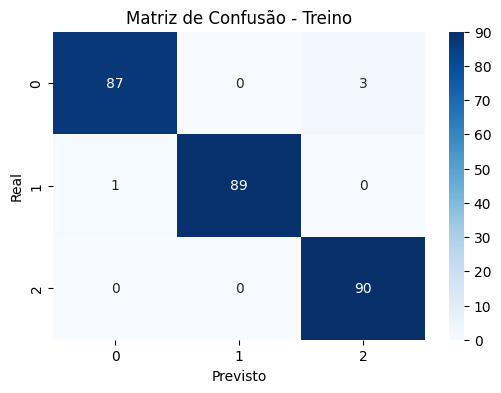

In [4]:

# Fazer previsões no treino

y_pred_train = modelo_nb.predict(X_train)

# Calcular métricas

# Acurácia
accuracy_train = accuracy_score(y_train, y_pred_train)

# Recall (multi classe)
recall_train = recall_score(
    y_train,
    y_pred_train,
    average='macro'
)

print("Acurácia (treino):", accuracy_train)
print("Recall (treino):", recall_train)

# Matriz de confusão

cm = confusion_matrix(y_train, y_pred_train)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusão - Treino")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

O modelo Naive Bayes apresentou excelente desempenho na base de treinamento, obtendo uma a**curácia de 0.985 e recall de 0.985**. Esses valores indicam que o modelo conseguiu classificar corretamente a grande maioria dos registros da base de treino.
- Ao observar a matriz de confusão, percebe-se que houve poucos erros de classificação, com a maior parte dos registros sendo corretamente prevista em suas respectivas classes. Isso demonstra que o modelo conseguiu aprender bem os padrões presentes nos dados de treinamento e identificar corretamente as diferenças entre os níveis de score de crédito.

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados, da mesma forma que fez acima. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

Acurácia (teste): 1.0
Recall (teste): 1.0


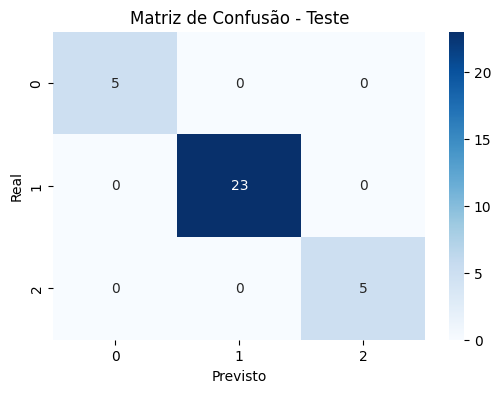

In [5]:
# Previsões no teste

y_pred_test = modelo_nb.predict(X_test)

# Métricas

from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Acurácia
accuracy_test = accuracy_score(y_test, y_pred_test)

# Recall (multi classe)
recall_test = recall_score(
    y_test,
    y_pred_test,
    average='macro'
)

print("Acurácia (teste):", accuracy_test)
print("Recall (teste):", recall_test)

# Matriz de confusão

cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusão - Teste")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

- Ao aplicar o modelo Naive Bayes aos dados de teste, o modelo apresentou um desempenho excelente, obtendo acurácia de 1.0 e recall de 1.0, indicando que todos os registros da base de teste foram corretamente classificados.
- A matriz de confusão confirma esse resultado, mostrando que não houve erros de classificação entre as classes previstas e reais.
- Comparando os resultados das bases de treino e teste, observa-se que o modelo manteve um desempenho consistente, com métricas altas em ambas as bases. Isso indica que o modelo possui boa capacidade de generalização e não apresentou sinais de overfitting, conseguindo aplicar corretamente o aprendizado obtido no treino aos novos dados de teste.

# 5) Descreva com suas palavras o projeto desenvolvido nessa atividade e qual o nosso objetivo principal ao aplicarmos o algoritmo de naive bayes a base de crédito.
Utilize pelo menos 4 linhas.

Dica: Caso você ainda esteja tendo dificuldade em visualizar a aplicação dos projetos e objetivo, consulte seus tutores!

Neste projeto foi aplicado o algoritmo de Naive Bayes em uma base de dados de crédito com o **objetivo de prever o score de crédito dos clientes.** Inicialmente, os dados passaram por etapas de tratamento, **balanceamento das classes e separação em bases de treinamento e teste**, garantindo que o modelo pudesse aprender corretamente os padrões existentes nos dados. Em seguida, o modelo foi treinado com a base de treinamento e **avaliado utilizando métricas como acurácia, recall e matriz de confusão**, permitindo analisar seu desempenho.